In [1]:
pip install -Uq diffusers transformers fastcore

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip cache purge
!pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu118

In [7]:
import logging
from pathlib import Path
import matplotlib.pyplot as plt
from fastcore.all import concat
from PIL import Image
import torch
logging.disable(logging.WARNING)
torch.manual_seed(1)


Stable diffusion pipeline


In [ ]:
pipeline = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", variant="fp16", torch_dtype=torch.float16).to('cuda')

In [ ]:
prompt = "A realistic sports photograph of Cristiano Ronaldo celebrating a World Cup victory, holding the golden worldcup trophy, Portugal jersey number 7, surrounded by teammates and fans, authentic football stadium atmosphere, captured by a professional sports photographer, Canon EOS R5, 400mm telephoto lens, natural lighting, realistic skin texture, sharp details, documentary photography style"
pipeline(prompt = prompt).images[0]

In [ ]:
torch.manual_seed(1024)
pipeline(prompt, num_inference_steps=3).images[0]  #showing the image after denoising step number 3

In [ ]:
torch.manual_seed(1024)
pipeline(prompt, num_inference_steps=100).images[0]

Classifier-Free Guidance

In [5]:
def image_grid(imgs, rows ,cols):
    w,h = imgs[0].size    #extraction of width and height of the image
    grid = Image.new('RGB', size=(cols*w, rows*h))  #creation of image background field
    for i, img in enumerate(imgs):
        grid.paste(img,box=(i%cols*w, i//cols*h))
    return grid    


In [ ]:
num_rows , num_cols = 2,3
prompts = [prompt] * num_cols


In [ ]:
pipeline(prompt, guidance_scale=7.5).images[0]

Using different values of guidance scale inorder to display various qualities of images

In [ ]:
images = concat(pipeline(prompt, guidance_scale=g).images for g in [1,2.5,3.5,7.5,11,14])
image_grid(images, num_rows , num_cols)

Use of negative prompt to make the image more realistic

In [ ]:
pipeline(prompt, guidance_scale = 10, negative_prompt = "cartoon, anime, illustration, painting, sketch, CGI, 3D render, doll, toy, low quality, worst quality, blurry, out of focus, soft focus, motion blur, noisy, grainy, pixelated, low resolution, oversaturated, unrealistic colors, unrealistic lighting, flat lighting, plastic skin, waxy skin, fake skin, bad anatomy, bad proportions, deformed, distorted face, asymmetrical eyes, cross-eyed, malformed hands, extra fingers, fused fingers, missing fingers, extra limbs, duplicate body, duplicate person, poorly drawn face, poorly drawn hands, unnatural pose, watermark, logo, text, signature, frame, border, cropped, jpeg artifacts").images[0]

In [ ]:
from PIL import Image
curry_img = Image.open('/kaggle/input/datasets/asoktamang/steph-curry/steph curry.jpg').convert('RGB')

Use of image to image pipeline

In [ ]:
from diffusers import StableDiffusionXLImg2ImgPipeline
pipeline = StableDiffusionXLImg2ImgPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", variant="fp16", torch_dtype=torch.float16).to('cuda')


In [ ]:
prompt = 'NBA player Stephen Curry dribbling basketball'
images = pipeline(prompt = prompt, image = curry_img, num_images_per_prompt = 1, strength = 0.8, num_inference_steps = 50).images
image_grid(images, rows = 1 ,cols = 1)

In [ ]:
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", variant="fp16", torch_dtype=torch.float16) 
pipe = pipe.to("cuda")

URL of embedding layers 

In [ ]:
from fastdownload import FastDownload
embs_url = "https://huggingface.co/sd-concepts-library/takuji-kawano/resolve/main/learned_embeds.bin"
embeds_path = FastDownload().download(embs_url)  #downloading the embedding layer
embeds_dict = torch.load(str(embeds_path), map_location = 'cpu',weights_only = False)   #loading the token and embedding vector from saved trained embeddings

In [ ]:
tokenizer = pipe.tokenizer  #extracting the tokenizer of pipeline
text_encoder = pipe.text_encoder  #extracting the text encoder of pipeline 
new_token , embeds = next(iter(embeds_dict.items()))    #extraction of the token and the embedding from the downloaded embedding url
embeds = embeds.to(text_encoder.dtype)  #converting the type of downloaded embedding into the type of text encoder of the pipeline


addition of new tokenizer in the tokenizer of pipeline and new embedding in the embedding layer of pipeline

In [ ]:
assert tokenizer.add_tokens(new_token) == 1 , 'The token already exists!'

In [ ]:
text_encoder.resize_token_embeddings(len(tokenizer))  #as we have added new token in tokenizer, so we must also resize the text encoder as the same size of tokenizer
new_token_id = tokenizer.convert_tokens_to_ids(new_token)   #converting the new token into id with the help of tokenizer
text_encoder.get_input_embeddings().weight.data[new_token_id] = embeds  #here we are storing the new embedding vector for the new token using new token id in text_encoder

In [ ]:
torch.manual_seed(1000)
image = pipe("street fighter character ryu").images[0]
image

In [ ]:
!git clone https://github.com/huggingface/diffusers
!cd diffusers && pip install -e .

In [ ]:
!cd /kaggle/working/diffusers/examples/dreambooth && pip install -r requirements.txt

In [ ]:
!accelerate config default

Upgrading the Parameter-Efficient fine tuning package version

In [ ]:
!pip install -U peft --break-system-packages

In [ ]:
!pip install bitsandbytes --break-system-packages

Moving into the required path and training the model on our datas

In [ ]:
%%bash
cd "/kaggle/working/diffusers/examples/dreambooth"

export MODEL_NAME="CompVis/stable-diffusion-v1-4"
export INSTANCE_DIR="/kaggle/input/datasets/asoktamang/asok-tamang"
export OUTPUT_DIR="my-dreambooth-model"

accelerate launch train_dreambooth.py \
  --pretrained_model_name_or_path=$MODEL_NAME \
  --instance_data_dir=$INSTANCE_DIR \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="a photo of sks asok" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --gradient_checkpointing \
  --use_8bit_adam \
  --mixed_precision="fp16" \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=400

Loading the model trained on our data

In [ ]:
!pip uninstall -y kornia --break-system-packages

In [2]:
from diffusers import StableDiffusionPipeline

In [3]:
import torch
pipe = StableDiffusionPipeline.from_pretrained(
    "/kaggle/working/diffusers/examples/dreambooth/my-dreambooth-model",
    torch_dtype=torch.float16
).to("cuda")

/kaggle/working/diffusers/src/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [4]:
from huggingface_hub import login
login()  

pipe.push_to_hub("Asoktamang11/my-dreambooth-asok")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CommitInfo(commit_url='https://huggingface.co/Asoktamang11/my-dreambooth-asok/commit/136fd67d2ac3e03204f7b91672f2fce970b543e4', commit_message='Upload StableDiffusionPipeline', commit_description='', oid='136fd67d2ac3e03204f7b91672f2fce970b543e4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Asoktamang11/my-dreambooth-asok', endpoint='https://huggingface.co', repo_type='model', repo_id='Asoktamang11/my-dreambooth-asok'), pr_revision=None, pr_num=None)

Me in different body,

  0%|          | 0/50 [00:00<?, ?it/s]

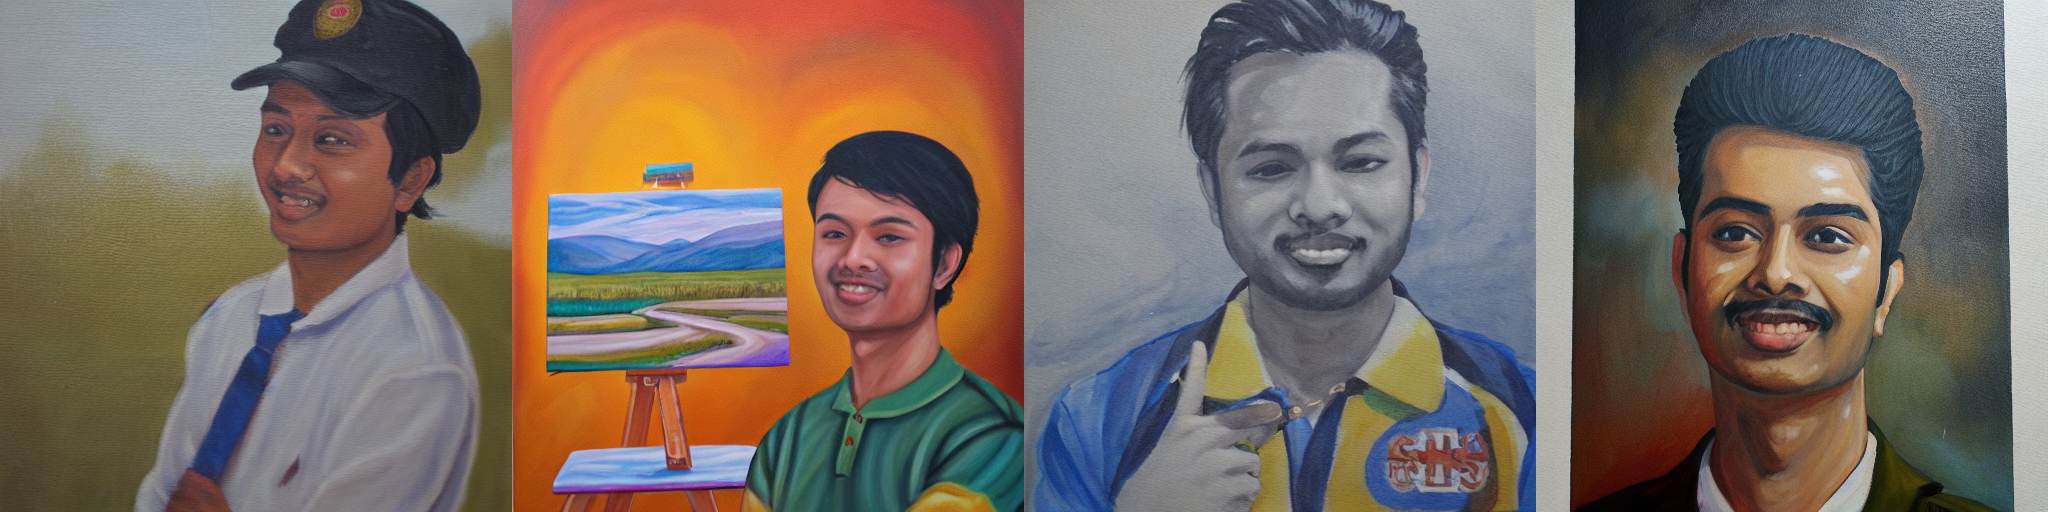

In [10]:
torch.manual_seed(1000)

prompt = "painting of sks asok"
images = pipe(prompt, num_images_per_prompt=4).images
image_grid(images, 1, 4)